# Data Preparation

### Imports & Paths


In [2]:
import os
from pathlib import Path

import pandas as pd
from PIL import Image
from tqdm import tqdm

In [3]:
DATA_DIR = Path("../data/raw/Lung Disease Dataset")

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

print(TRAIN_DIR)
print(VAL_DIR)
print(TEST_DIR)

..\data\raw\Lung Disease Dataset\train
..\data\raw\Lung Disease Dataset\val
..\data\raw\Lung Disease Dataset\test


### Dataset Audit

In [4]:
print("TRAIN CLASSES\n")

classes = sorted([
    folder.name
    for folder in TRAIN_DIR.iterdir()
    if folder.is_dir()
])

for cls in classes:
    print(cls)

TRAIN CLASSES

Bacterial Pneumonia
Corona Virus Disease
Normal
Tuberculosis
Viral Pneumonia


### Count Images

In [5]:
stats = []

for split_name, split_dir in zip(
    ["Train", "Validation", "Test"],
    [TRAIN_DIR, VAL_DIR, TEST_DIR]
):

    for cls in classes:

        count = len([
            img for img in (split_dir / cls).iterdir()
            if img.suffix.lower() in [".jpg", ".jpeg", ".png"]
        ])

        stats.append({
            "Split": split_name,
            "Class": cls,
            "Images": count
        })

stats_df = pd.DataFrame(stats)

stats_df

,Split,Class,Images
0,Train,Bacterial Pneumonia,1205
1,Train,Corona Virus Disease,1218
2,Train,Normal,1207
3,Train,Tuberculosis,1220
4,Train,Viral Pneumonia,1204
5,Validation,Bacterial Pneumonia,401
6,Validation,Corona Virus Disease,406
7,Validation,Normal,402
8,Validation,Tuberculosis,406
9,Validation,Viral Pneumonia,401


In [13]:
stats_df.to_csv(
    "../data/Stats/dataset_stats.csv",
    index=False
)

print("dataset_stats.csv saved")

dataset_stats.csv saved


In [7]:
summary = stats_df.pivot(
    index="Class",
    columns="Split",
    values="Images"
)

summary["Total"] = (
    summary["Train"] +
    summary["Validation"] +
    summary["Test"]
)

summary

Split,Test,Train,Validation,Total
Class,,,,
Bacterial Pneumonia,403,1205,401,2009
Corona Virus Disease,407,1218,406,2031
Normal,404,1207,402,2013
Tuberculosis,408,1220,406,2034
Viral Pneumonia,403,1204,401,2008


### Corrupted Image Check

In [8]:
corrupted_files = []

for split_dir in [TRAIN_DIR, VAL_DIR, TEST_DIR]:

    for cls in classes:

        folder = split_dir / cls

        for img_path in tqdm(
            list(folder.iterdir()),
            desc=f"{split_dir.name}-{cls}"
        ):

            try:
                img = Image.open(img_path)
                img.verify()

            except Exception:
                corrupted_files.append(str(img_path))

print("\nCorrupted Images:", len(corrupted_files))

test-Viral Pneumonia: 100%|██████████| 403/403 [00:06<00:00, 62.93it/s]


Corrupted Images: 0


### Image Size Analysis

In [9]:
sizes = []

for split_dir in [TRAIN_DIR]:

    for cls in classes:

        folder = split_dir / cls

        for img_path in tqdm(
            list(folder.iterdir()),
            desc=cls
        ):

            try:

                img = Image.open(img_path)

                sizes.append([
                    img.width,
                    img.height
                ])

            except:
                pass

sizes_df = pd.DataFrame(
    sizes,
    columns=["Width", "Height"]
)

sizes_df.head()

Viral Pneumonia: 100%|██████████| 1204/1204 [00:00<00:00, 2125.90it/s]


,Width,Height
0,400,300
1,400,300
2,400,300
3,400,300
4,400,300


In [10]:
print("Average Width :", sizes_df["Width"].mean())
print("Average Height:", sizes_df["Height"].mean())

print("\nMin Width :", sizes_df["Width"].min())
print("Max Width :", sizes_df["Width"].max())

print("\nMin Height :", sizes_df["Height"].min())
print("Max Height :", sizes_df["Height"].max())

Average Width : 1023.2710604558969
Average Height: 808.399735711926

Min Width : 132
Max Width : 5623

Min Height : 93
Max Height : 4757


In [12]:
### Final Dataset Report

In [11]:
print("="*50)
print("DATASET REPORT")
print("="*50)

print("\nClasses:", len(classes))

for cls in classes:
    print(cls)

print("\nTotal Images:")

print(stats_df["Images"].sum())

print("\nCorrupted Images:")

print(len(corrupted_files))

DATASET REPORT

Classes: 5
Bacterial Pneumonia
Corona Virus Disease
Normal
Tuberculosis
Viral Pneumonia

Total Images:
10095

Corrupted Images:
0


## Storing Stats

In [18]:
from pathlib import Path

STATS_DIR = Path("../data/Stats")

STATS_DIR.mkdir(parents=True, exist_ok=True)

In [19]:
stats_df.to_csv(
    STATS_DIR / "dataset_stats.csv",
    index=False
)

In [20]:
summary.to_csv(
    STATS_DIR / "class_distribution.csv"
)

In [21]:
import json

class_mapping = {
    "Bacterial Pneumonia": 0,
    "Corona Virus Disease": 1,
    "Normal": 2,
    "Tuberculosis": 3,
    "Viral Pneumonia": 4
}

with open(STATS_DIR / "class_mapping.json", "w") as f:
    json.dump(class_mapping, f, indent=4)

In [22]:
metadata = {
    "dataset_name": "Lung Disease Dataset",
    "num_classes": 5,
    "total_images": 10095,
    "train_images": 6054,
    "val_images": 2016,
    "test_images": 2025,
    "corrupted_images": 0,
    "balanced_dataset": True,
    "classes": list(class_mapping.keys())
}

with open(STATS_DIR / "dataset_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

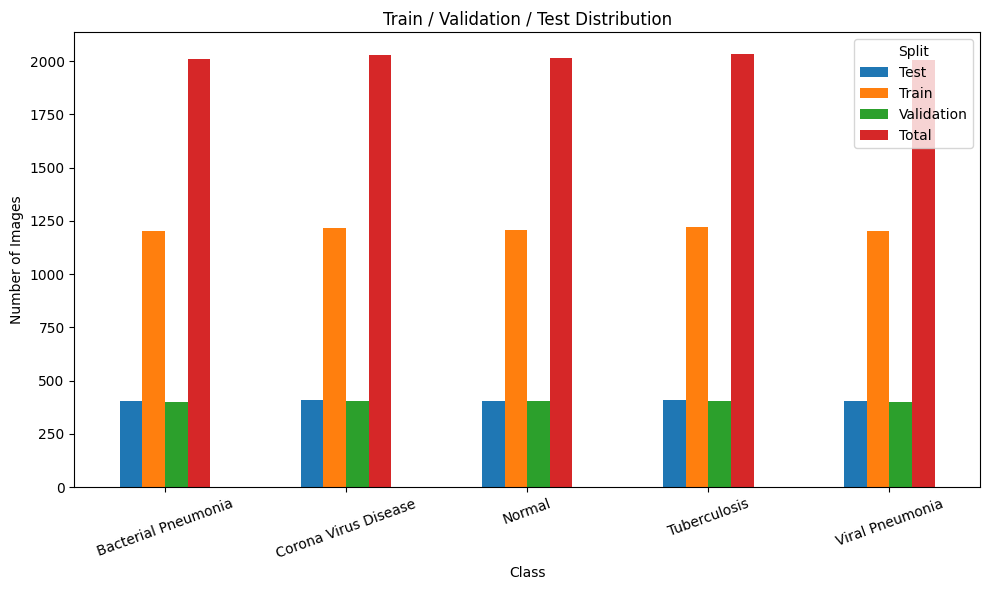

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

summary.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Train / Validation / Test Distribution")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig("../data/stats/split_distribution.png")
plt.show()

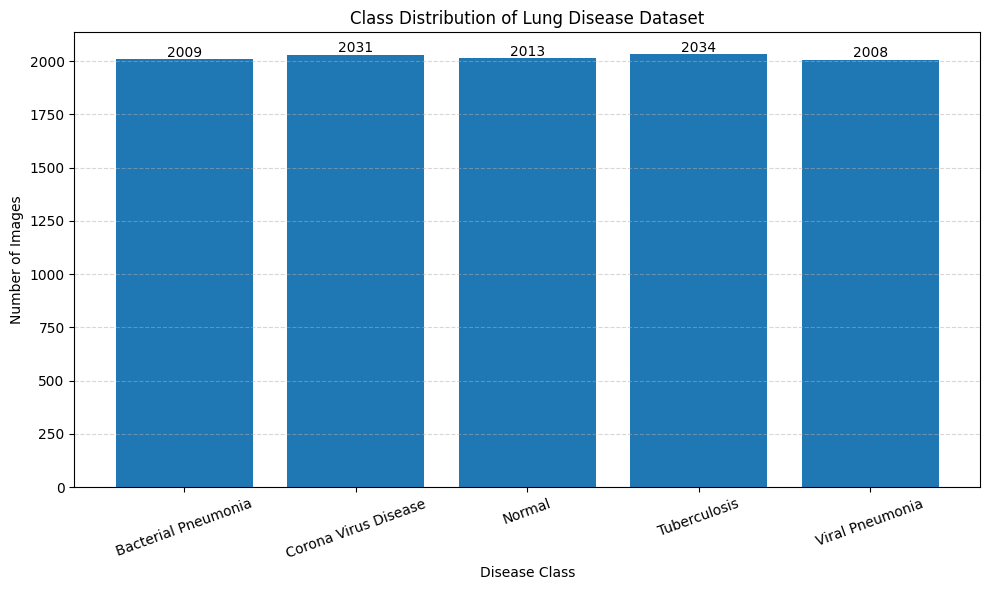

Saved to: ..\data\stats\class_distribution.png


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Create stats directory if it doesn't exist
STATS_DIR = Path("../data/stats")
STATS_DIR.mkdir(parents=True, exist_ok=True)

# Create class totals from summary table
class_totals = summary["Total"]

# Plot
plt.figure(figsize=(10, 6))

bars = plt.bar(
    class_totals.index,
    class_totals.values
)

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 10,
        f"{int(height)}",
        ha="center"
    )

plt.title("Class Distribution of Lung Disease Dataset")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

# Save figure
save_path = STATS_DIR / "class_distribution.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved to: {save_path}")